In [102]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;
from sklearn.model_selection import train_test_split;
from sklearn.linear_model import LinearRegression;
from sklearn.metrics import mean_squared_error, r2_score;
from xgboost import XGBRegressor;
from sklearn.preprocessing import LabelEncoder;
from sklearn.ensemble import RandomForestRegressor;
from sklearn.metrics import mean_absolute_error;
import warnings
warnings.filterwarnings("ignore")
from lightgbm import LGBMRegressor;


In [ ]:
from extraction_dataset_for_xgboost.ipynb import 

In [187]:
#load the dataset
dataset_files = [
    ('2023', '../classes/master_dataset_partie2_2023.csv'),
    ('2024', '../classes/master_dataset_partie2_2024_stint.csv'),
]

frames = []
for year, path in dataset_files:
    try:
        current = pd.read_csv(path)
        if 'Year' not in current.columns:
            current['Year'] = int(year)
        frames.append(current)
        print(f'Loaded {path} -> {len(current)} rows')
    except FileNotFoundError:
        print(f'Skipped missing file: {path}')

if not frames:
    raise FileNotFoundError('Aucun fichier dataset 2023/2024/2025 introuvable')

df = pd.concat(frames, ignore_index=True)
print(df.info())
#check for missing values
print(df.isnull().sum())
print(df.describe())
print(df.dtypes)

Loaded ../classes/master_dataset_partie2_2023.csv -> 17865 rows
Loaded ../classes/master_dataset_partie2_2024_stint.csv -> 18877 rows
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36742 entries, 0 to 36741
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     36742 non-null  int64  
 1   Event                    36742 non-null  object 
 2   Driver                   36742 non-null  int64  
 3   Compound                 36742 non-null  object 
 4   CompoundEncoded          36742 non-null  int64  
 5   TyreLife                 36742 non-null  float64
 6   TrackTemp                36742 non-null  float64
 7   FuelLoad                 36742 non-null  float64
 8   Abrasivity               36742 non-null  float64
 9   LateralEnergy            36742 non-null  float64
 10  DeltaToBest              36742 non-null  float64
 11  LapNumber                36742 non-null  float64
 

In [208]:
def compute_delta_correctly(df):
    required = {'Driver', 'Event', 'Stint', 'LapNumber', 'CorrectedLapTime_Global'}
    if not required.issubset(df.columns):
        return df

    df = df.sort_values(['Driver', 'Event', 'Stint', 'LapNumber']).copy()

    # Min progressif: seulement les tours passes
    df['BestCorrectedByStint'] = (
        df.groupby(['Driver', 'Event', 'Stint'])['CorrectedLapTime_Global']
        .transform(lambda x: x.expanding().min())
    )

    df['DeltaToBest'] = df['CorrectedLapTime_Global'] - df['BestCorrectedByStint']
    return df


def preprocess_data(df):
    df = df.copy()

    # Recompute DeltaToBest using progressive best-per-stint logic.
    df = compute_delta_correctly(df)

    # Support both possible naming conventions.
    delta_col = 'deltaToBest' if 'deltaToBest' in df.columns else 'DeltaToBest'

    # Encode season chronology from Bahrain 2023 to Abu Dhabi 2024.
    RACE_ORDER_2023_2024 = {
        (2023, 'Bahrain Grand Prix'): 1,
        (2023, 'Saudi Arabian Grand Prix'): 2,
        (2023, 'Australian Grand Prix'): 3,
        (2023, 'Azerbaijan Grand Prix'): 4,
        (2023, 'Miami Grand Prix'): 5,
        (2023, 'Monaco Grand Prix'): 6,
        (2023, 'Spanish Grand Prix'): 7,
        (2023, 'Canadian Grand Prix'): 8,
        (2023, 'Austrian Grand Prix'): 9,
        (2023, 'British Grand Prix'): 10,
        (2023, 'Hungarian Grand Prix'): 11,
        (2023, 'Belgian Grand Prix'): 12,
        (2023, 'Dutch Grand Prix'): 13,
        (2023, 'Italian Grand Prix'): 14,
        (2023, 'Singapore Grand Prix'): 15,
        (2023, 'Japanese Grand Prix'): 16,
        (2023, 'Qatar Grand Prix'): 17,
        (2023, 'United States Grand Prix'): 18,
        (2023, 'Mexico City Grand Prix'): 19,
        (2023, 'Sao Paulo Grand Prix'): 20,
        (2023, 'Las Vegas Grand Prix'): 21,
        (2023, 'Abu Dhabi Grand Prix'): 22,
        (2024, 'Bahrain Grand Prix'): 23,
        (2024, 'Saudi Arabian Grand Prix'): 24,
        (2024, 'Australian Grand Prix'): 25,
        (2024, 'Japanese Grand Prix'): 26,
        (2024, 'Chinese Grand Prix'): 27,
        (2024, 'Miami Grand Prix'): 28,
        (2024, 'Emilia Romagna Grand Prix'): 29,
        (2024, 'Monaco Grand Prix'): 30,
        (2024, 'Canadian Grand Prix'): 31,
        (2024, 'Spanish Grand Prix'): 32,
        (2024, 'Austrian Grand Prix'): 33,
        (2024, 'British Grand Prix'): 34,
        (2024, 'Hungarian Grand Prix'): 35,
        (2024, 'Belgian Grand Prix'): 36,
        (2024, 'Dutch Grand Prix'): 37,
        (2024, 'Italian Grand Prix'): 38,
        (2024, 'Azerbaijan Grand Prix'): 39,
        (2024, 'Singapore Grand Prix'): 40,
        (2024, 'United States Grand Prix'): 41,
        (2024, 'Mexico City Grand Prix'): 42,
        (2024, 'Sao Paulo Grand Prix'): 43,
        (2024, 'Las Vegas Grand Prix'): 44,
        (2024, 'Qatar Grand Prix'): 45,
        (2024, 'Abu Dhabi Grand Prix'): 46,
    }

    if {'Year', 'Event'}.issubset(df.columns):
        event_for_map = df['Event'].astype(str).str.replace('São Paulo Grand Prix', 'Sao Paulo Grand Prix', regex=False)
        year_for_map = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')
        race_keys = [
            (int(y), e) if pd.notna(y) else None
            for y, e in zip(year_for_map, event_for_map)
        ]
        df['RaceNumber'] = pd.Series(race_keys, index=df.index).map(RACE_ORDER_2023_2024)

    # Driver -> Team mapping for 2023 + 2024 (year-aware first, then fallback by driver)
    DRIVER_TEAM_BY_YEAR = {
        (2023, 'VER'): 'Red Bull', (2023, 'PER'): 'Red Bull',
        (2023, 'HAM'): 'Mercedes', (2023, 'RUS'): 'Mercedes',
        (2023, 'LEC'): 'Ferrari', (2023, 'SAI'): 'Ferrari',
        (2023, 'NOR'): 'McLaren', (2023, 'PIA'): 'McLaren',
        (2023, 'ALO'): 'Aston Martin', (2023, 'STR'): 'Aston Martin',
        (2023, 'OCO'): 'Alpine', (2023, 'GAS'): 'Alpine',
        (2023, 'BOT'): 'Sauber', (2023, 'ZHO'): 'Sauber',
        (2023, 'ALB'): 'Williams', (2023, 'SAR'): 'Williams',
        (2023, 'MAG'): 'Haas', (2023, 'HUL'): 'Haas',
        (2023, 'TSU'): 'RB', (2023, 'RIC'): 'RB',
        (2023, 'DEV'): 'RB', (2023, 'LAW'): 'RB',

        (2024, 'VER'): 'Red Bull', (2024, 'PER'): 'Red Bull',
        (2024, 'HAM'): 'Mercedes', (2024, 'RUS'): 'Mercedes',
        (2024, 'LEC'): 'Ferrari', (2024, 'SAI'): 'Ferrari',
        (2024, 'NOR'): 'McLaren', (2024, 'PIA'): 'McLaren',
        (2024, 'ALO'): 'Aston Martin', (2024, 'STR'): 'Aston Martin',
        (2024, 'OCO'): 'Alpine', (2024, 'GAS'): 'Alpine',
        (2024, 'BOT'): 'Sauber', (2024, 'ZHO'): 'Sauber',
        (2024, 'ALB'): 'Williams', (2024, 'SAR'): 'Williams',
        (2024, 'MAG'): 'Haas', (2024, 'HUL'): 'Haas',
        (2024, 'TSU'): 'RB', (2024, 'RIC'): 'RB',
    }
    DRIVER_TO_TEAM_FALLBACK = {
        'VER': 'Red Bull', 'PER': 'Red Bull',
        'HAM': 'Mercedes', 'RUS': 'Mercedes',
        'LEC': 'Ferrari', 'SAI': 'Ferrari',
        'NOR': 'McLaren', 'PIA': 'McLaren',
        'ALO': 'Aston Martin', 'STR': 'Aston Martin',
        'OCO': 'Alpine', 'GAS': 'Alpine',
        'BOT': 'Sauber', 'ZHO': 'Sauber',
        'ALB': 'Williams', 'SAR': 'Williams',
        'MAG': 'Haas', 'HUL': 'Haas',
        'TSU': 'RB', 'RIC': 'RB', 'DEV': 'RB', 'LAW': 'RB'
    }

    if {'Year', 'Driver'}.issubset(df.columns):
        year_for_team = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')
        driver_for_team = df['Driver'].astype(str)
        team_keys = [
            (int(y), d) if pd.notna(y) else None
            for y, d in zip(year_for_team, driver_for_team)
        ]
        team_series = pd.Series(team_keys, index=df.index).map(DRIVER_TEAM_BY_YEAR)
        team_fallback = driver_for_team.map(DRIVER_TO_TEAM_FALLBACK)
        df['Team'] = team_series.fillna(team_fallback).fillna('Unknown')
    elif 'Driver' in df.columns:
        df['Team'] = df['Driver'].astype(str).map(DRIVER_TO_TEAM_FALLBACK).fillna('Unknown')

    if 'Team' in df.columns:
        le_team = LabelEncoder()
        df['TeamEncoded'] = le_team.fit_transform(df['Team'])

    if 'Event' in df.columns:
        le_event = LabelEncoder()
        df['EventEncoded'] = le_event.fit_transform(df['Event'])

    # Preserve season for later evaluation without using it as a feature.
    if 'Year' in df.columns:
        df['SeasonYear'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')
    elif 'year' in df.columns:
        df['SeasonYear'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

    # 1. Delta vitesse (variation intra-stint)
    if {'Driver', 'Stint', delta_col}.issubset(df.columns):
        df['delta_velocity'] = df.groupby(['Driver', 'Stint'])[delta_col].diff()

    # 2. Stress cumulatif
    df['lateral_stress_cumul'] = df['LateralEnergy'] * df['TyreLife']
    df['abrasive_stress_cumul'] = df['Abrasivity'] * df['TyreLife']

    # 3. Interaction thermique
    df['stress_x_temp'] = df['LateralEnergy'] * df['TrackTemp'] * df['TyreLife']

    # 4. Target
    if {'Driver', 'Stint', delta_col}.issubset(df.columns):
        df['delta_next_lap'] = df.groupby(['Driver', 'Stint'])[delta_col].shift(-1)

    # 5. Drop derniere ligne de chaque stint (target = NaN)
    if 'delta_next_lap' in df.columns:
        df = df.dropna(subset=['delta_next_lap'])

    # 6. Feature engineering that still needs Driver/Event before they are dropped
    if 'RaceNumber' in df.columns:
        df = df[df['RaceNumber'] != 6 ] 
        df=df[df["RaceNumber"] != 30 ]  # Monaco = course 6,30

    if {'CompoundEncoded', 'Abrasivity'}.issubset(df.columns):
        df['compound_x_abrasivity'] = df['CompoundEncoded'] * df['Abrasivity']
    if {'CompoundEncoded', 'LateralEnergy'}.issubset(df.columns):
        df['compound_x_lateral'] = df['CompoundEncoded'] * df['LateralEnergy']
    if {'CompoundEncoded', 'TyreLife'}.issubset(df.columns):
        df['compound_x_tyrelife'] = df['CompoundEncoded'] * df['TyreLife']

    if {'Driver', 'RaceNumber', 'Stint', 'LapNumber'}.issubset(df.columns):
        df = df.sort_values(['Driver', 'RaceNumber', 'Stint', 'LapNumber'])
        df['prev_stint_max_delta'] = (
            df.groupby(['Driver', 'RaceNumber'])
            .apply(lambda g: g.groupby('Stint')['DeltaToBest']
                   .max().shift(1).reindex(g.index, method='ffill'))
            .reset_index(level=[0, 1], drop=True)
        )

    if {'RaceNumber', 'Stint', 'TyreLife'}.issubset(df.columns):
        if 'Driver' in df.columns:
            df['stint_length'] = df.groupby(['Driver', 'RaceNumber', 'Stint'])['TyreLife'].transform('max')
        else:
            df['stint_length'] = df.groupby(['RaceNumber', 'Stint'])['TyreLife'].transform('max')
        df['tyre_life_pct'] = df['TyreLife'] / df['stint_length']

    # 6. Remove raw categorical columns after encoding
    df = df.drop(columns=['Event', 'Driver', 'Compound', 'Year', 'year', 'Team', 'YearEncoded'], errors='ignore')

    return df

In [189]:
df = preprocess_data(df)
print(df.info(30))

<class 'pandas.core.frame.DataFrame'>
Index: 34936 entries, 3619 to 18718
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CompoundEncoded          34936 non-null  int64  
 1   TyreLife                 34936 non-null  float64
 2   TrackTemp                34936 non-null  float64
 3   FuelLoad                 34936 non-null  float64
 4   Abrasivity               34936 non-null  float64
 5   LateralEnergy            34936 non-null  float64
 6   DeltaToBest              34936 non-null  float64
 7   LapNumber                34936 non-null  float64
 8   Stint                    34936 non-null  float64
 9   CorrectedLapTime_Global  34936 non-null  float64
 10  BestCorrectedByStint     34936 non-null  float64
 11  RaceNumber               34936 non-null  int64  
 12  TeamEncoded              34936 non-null  int64  
 13  EventEncoded             34936 non-null  int64  
 14  delta_velocity          

In [190]:
df = df.drop(columns=[
    'BestCorrectedByStint',     # leakage (utilise pour calculer DeltaToBest)
    'CorrectedLapTime_Global',  # leakage indirect
    'EventEncoded',             # redondant avec RaceNumber
], errors='ignore')

# Premier tour de chaque stint: pas de tour precedent
if 'delta_velocity' in df.columns:
    df['delta_velocity'] = df['delta_velocity'].fillna(0)

corr = df[['LapNumber', 'TyreLife']].corr().iloc[0, 1]
print(f"Correlation LapNumber/TyreLife : {corr:.3f}")

# Si > 0.85, supprimer LapNumber
if corr > 0.85:
    df = df.drop(columns=['LapNumber'], errors='ignore')

Correlation LapNumber/TyreLife : 0.525


In [191]:
import matplotlib.pyplot as plt

print(df['delta_next_lap'].describe())
#         mean   std    min     max
# Attendu: ~0.3  ~0.4   0.0    ~3.0

# Chercher les outliers
print(f"Valeurs > 3s : {(df['delta_next_lap'] > 3).sum()}")
print(f"Valeurs < 0  : {(df['delta_next_lap'] < 0).sum()}")

# Clipper les outliers extrêmes
df = df[df['delta_next_lap'].between(0, 3)]

count    34936.000000
mean         0.877792
std          1.021704
min          0.000000
25%          0.172071
50%          0.632000
75%          1.252559
max         34.482863
Name: delta_next_lap, dtype: float64
Valeurs > 3s : 1199
Valeurs < 0  : 0


In [192]:
# Vérifier qu'il n'y a pas de valeurs aberrantes extrêmes
# qui pourraient ralentir l'apprentissage

print(df[['TyreLife', 'TrackTemp', 'FuelLoad', 
          'lateral_stress_cumul', 'stress_x_temp']].describe())

# stress_x_temp = lateral × TrackTemp × TyreLife
# peut atteindre 5 × 50 × 40 = 10000
# → pas un problème pour XGBoost mais vérifie que c'est cohérent



           TyreLife     TrackTemp      FuelLoad  lateral_stress_cumul  \
count  33737.000000  33737.000000  33737.000000          33737.000000   
mean      14.728636     35.424540     29.447432             47.965480   
std        9.366327      7.886723     17.587962             33.016125   
min        1.000000     16.700000      0.000000              1.800000   
25%        7.000000     30.400000     14.000000             22.400000   
50%       13.000000     34.800000     29.000000             40.600000   
75%       20.000000     42.300000     44.000000             65.100000   
max       58.000000     51.700000     71.000000            250.800000   

       stress_x_temp  
count   33737.000000  
mean     1666.466844  
std      1117.707645  
min        32.940000  
25%       768.600000  
50%      1441.440000  
75%      2362.500000  
max      7975.440000  


In [121]:
# Bloc déplacé dans preprocess_data pour eviter la dependance a Driver apres suppression
pass

In [209]:
import numpy as np

# Liste de toutes les courses
all_races = df['RaceNumber'].unique()  # 1 à 23 (sans Monaco=8)

# Split aléatoire par course (pas par tour)
np.random.seed(42)
test_races = np.random.choice(all_races, size=10, replace=False)
train_races = np.array([r for r in all_races if r not in test_races])

print(f"Courses test  : {sorted(test_races)}")
print(f"Courses train : {sorted(train_races)}")

train = df[df['RaceNumber'].isin(train_races)]
test  = df[df['RaceNumber'].isin(test_races)]

X_train = train.drop(columns=['delta_next_lap', 'SeasonYear'], errors='ignore')
y_train = train['delta_next_lap']

X_test = test.drop(columns=['delta_next_lap', 'SeasonYear'], errors='ignore')
y_test = test['delta_next_lap']

print(f"Train : {len(train)} lignes")
print(f"Test  : {len(test)} lignes")

Courses test  : [np.int64(5), np.int64(8), np.int64(10), np.int64(15), np.int64(22), np.int64(27), np.int64(28), np.int64(33), np.int64(45), np.int64(46)]
Courses train : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(9), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(16), np.int64(17), np.int64(19), np.int64(20), np.int64(21), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(29), np.int64(31), np.int64(32), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(42), np.int64(44)]
Train : 24933 lignes
Test  : 8804 lignes


In [210]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

models = {
    'XGBoost': XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.7,
        colsample_bytree=0.7,
        min_child_weight=5,
        gamma=0.1,
        random_state=42,
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        min_child_samples=20,
        reg_lambda=1.0,
        num_leaves=63,
        verbose=-1,
    ),
    'RandomForest': RandomForestRegressor(
        n_estimators=500,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
}

results = {}
trained_models = {}
predictions = {}

for name, current_model in models.items():
    if name == 'XGBoost':
        current_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    elif name == 'LightGBM':
        current_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])
    else:
        current_model.fit(X_train, y_train)
    current_pred = current_model.predict(X_test)
    trained_models[name] = current_model
    predictions[name] = current_pred
    results[name] = {
        'MAE': mean_absolute_error(y_test, current_pred),
        'R2': r2_score(y_test, current_pred),
    }
    print(f"{name} -> MAE : {results[name]['MAE']:.4f}s | R² : {results[name]['R2']:.4f}")

# Garder XGBoost comme modèle actif pour les cellules suivantes
model = trained_models['XGBoost']
y_pred = predictions['XGBoost']

XGBoost -> MAE : 0.3178s | R² : 0.5272
LightGBM -> MAE : 0.3171s | R² : 0.5220
RandomForest -> MAE : 0.3133s | R² : 0.5174


ValueError: operands could not be broadcast together with shapes (8804,) (4509,) 

In [198]:
# 1. Résidus
y_pred = model.predict(X_test)
residuals = y_test - y_pred

print(pd.DataFrame({
    'y_test': y_test,
    'y_pred': y_pred,
    'residual': residuals
}).describe())

# 2. Feature importance en pourcentage (toutes les variables)
import pandas as pd
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance_pct = (importance / importance.sum()) * 100
importance_df = importance_pct.rename('importance_pct').to_frame()
importance_df['importance_pct'] = importance_df['importance_pct'].round(2)
importance_df['importance_pct'] = importance_df['importance_pct'].map(lambda x: f"{x:.2f}%")
print(importance_df.head(10))  # top 10 features

            y_test       y_pred     residual
count  8804.000000  8804.000000  8804.000000
mean      0.633515     0.675143    -0.041628
std       0.617044     0.435720     0.416649
min       0.000000    -0.213734    -2.103223
25%       0.125606     0.353083    -0.291822
50%       0.476000     0.542308    -0.100650
75%       0.973000     0.872929     0.155906
max       2.993000     2.549935     2.587055
                     importance_pct
delta_velocity               14.40%
DeltaToBest                  13.15%
prev_stint_max_delta          8.62%
tyre_life_pct                 7.65%
RaceNumber                    6.81%
FuelLoad                      6.70%
TrackTemp                     6.38%
LapNumber                     4.82%
Abrasivity                    4.49%
stress_x_temp                 3.95%


In [212]:
# Comparaison des résultats par saison sur le jeu de test
from sklearn.metrics import mean_absolute_error, r2_score

season_eval = test[['RaceNumber', 'delta_next_lap']].copy()
season_eval['SeasonYear'] = np.where(season_eval['RaceNumber'] >= 23, 2024, 2023)
season_eval['y_pred'] = y_pred

season_results = season_eval.groupby('SeasonYear').apply(lambda group: pd.Series({
    'MAE': mean_absolute_error(group['delta_next_lap'], group['y_pred']),
    'R2': r2_score(group['delta_next_lap'], group['y_pred']),
    'n': len(group)
}))

print(season_results.sort_index())

                 MAE        R2       n
SeasonYear                            
2023        0.323122  0.410555  4522.0
2024        0.312236  0.594104  4282.0


In [201]:
# Entraînement sur les 10 meilleures variables (d'après le modèle actuel)
from sklearn.metrics import mean_absolute_error, r2_score

# Recalcule des importances en numérique pour sélectionner proprement le top 10
importance_num = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top10_features = importance_num.head(10).index.tolist()
print('Top 10 features sélectionnées :')
print(top10_features)

# Sous-ensembles train/test sur ces 10 variables
X_train_top10 = X_train[top10_features].copy()
X_test_top10 = X_test[top10_features].copy()

# Nouveau modèle entraîné uniquement sur le top 10
model_top10 = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    min_child_samples=20,
    reg_lambda=1.0,
    num_leaves=63,
    verbose=-1,
    )

model_top10.fit(X_train_top10, y_train)
y_pred_top10 = model_top10.predict(X_test_top10)

print(f"MAE (Top 10) : {mean_absolute_error(y_test, y_pred_top10):.4f}s")
print(f"R²  (Top 10) : {r2_score(y_test, y_pred_top10):.4f}")

Top 10 features sélectionnées :
['delta_velocity', 'DeltaToBest', 'prev_stint_max_delta', 'tyre_life_pct', 'RaceNumber', 'FuelLoad', 'TrackTemp', 'LapNumber', 'Abrasivity', 'stress_x_temp']
MAE (Top 10) : 0.3124s
R²  (Top 10) : 0.5373


TeamEncoded
0    0.596884
Name: delta_next_lap, dtype: float64
TeamEncoded
0    0.573799
Name: delta_next_lap, dtype: float64


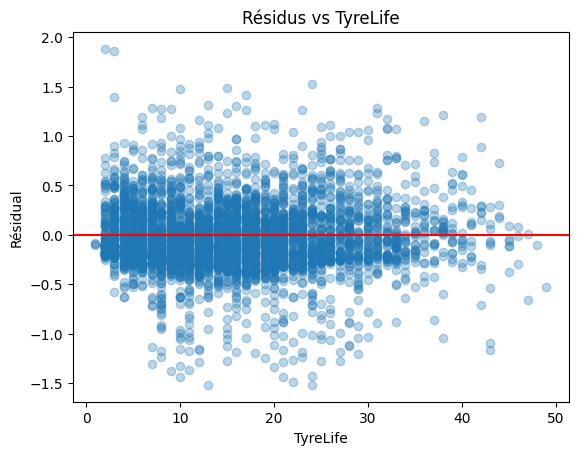

In [99]:
# 1. Vérifier TeamEncoded
print(df.groupby('TeamEncoded')['delta_next_lap'].mean().sort_values())
# Tu dois voir des différences claires entre teams

# 2. Vérifier la variance par team
print(df.groupby('TeamEncoded')['delta_next_lap'].std().sort_values())

# 3. Scatter plot résidus vs TyreLife
import matplotlib.pyplot as plt
plt.scatter(X_test['TyreLife'], residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel('TyreLife')
plt.ylabel('Résidual')
plt.title('Résidus vs TyreLife')
plt.show()
# Si pattern visible → TyreLife mal exploité

In [160]:
# Ton modèle est meilleur sur les vieux pneus
# C'est exactement ce dont tu as besoin pour la stratégie pit stop

# Vérifie ça
mask_late = X_test['TyreLife'] > 15
print(f"MAE TyreLife > 15 : {mean_absolute_error(y_test[mask_late], y_pred[mask_late]):.4f}s")
print(f"MAE TyreLife < 15 : {mean_absolute_error(y_test[~mask_late], y_pred[~mask_late]):.4f}s")

# Tu vas voir quelque chose comme :
# MAE TyreLife > 15 : 0.18s  ✅
# MAE TyreLife < 15 : 0.35s  ⚠️

MAE TyreLife > 15 : 0.3078s
MAE TyreLife < 15 : 0.3103s


In [101]:
# Regarder la distribution par tranche de TyreLife
import numpy as np

bins = [0, 5, 10, 15, 20, 25, 30, 50]
labels = ['1-5', '6-10', '11-15', '16-20', '21-25', '26-30', '30+']

X_test_copy = X_test.copy()
X_test_copy['y_test'] = y_test.values
X_test_copy['y_pred'] = y_pred
X_test_copy['bin'] = pd.cut(X_test_copy['TyreLife'], bins=bins, labels=labels)

print(X_test_copy.groupby('bin').agg(
    MAE=('y_test', lambda x: mean_absolute_error(
        x, X_test_copy.loc[x.index, 'y_pred'])),
    mean_delta=('y_test', 'mean'),
    count=('y_test', 'count')
))

            MAE  mean_delta  count
bin                               
1-5    0.228990    0.309838    546
6-10   0.268396    0.427801    834
11-15  0.258674    0.479101    787
16-20  0.264296    0.583908    678
21-25  0.295249    0.573705    519
26-30  0.297822    0.595143    328
30+    0.264469    0.597706    334
